In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import shap
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.io as pio
import plotly.express as px

import catboost as cb
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, make_scorer, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectFromModel

import optuna

import warnings
warnings.filterwarnings('ignore')

# NEE modelling

In [3]:
def plot_actual_vs_predicted(actual, predicted):
    """
    Plots the actual vs predicted values using Plotly.

    Parameters:
    actual (numpy.ndarray): Array of actual values.
    predicted (numpy.ndarray): Array of predicted values.
    """
    # Create the plot
    trace_actual = go.Scatter(
        x=np.arange(len(actual)),
        y=actual,
        mode='lines+markers',
        name='Actual'
    )

    trace_predicted = go.Scatter(
        x=np.arange(len(predicted)),
        y=predicted,
        mode='lines+markers',
        name='Predicted'
    )

    data = [trace_actual, trace_predicted]

    layout = go.Layout(
        title='Actual vs Predicted',
        xaxis=dict(title='Index'),
        yaxis=dict(title='Value')
    )

    fig = go.Figure(data=data, layout=layout)

    # Plot the figure inline
    pio.renderers.default = 'notebook'  # Ensure the renderer is set to 'notebook' for inline plotting
    fig.show()

In [4]:
class DataPreprocessing:
    def __init__(self, forest_path, no_forest_path):
        self.df_forest = pd.read_csv(forest_path)
        self.df_no_forest = pd.read_csv(no_forest_path)
        self.df = None

    def load_and_clean_data(self):
        # Drop 'Unnamed: 0' column
        self.df_no_forest.drop('Unnamed: 0', axis=1, inplace=True)
        self.df_forest.drop('Unnamed: 0', axis=1, inplace=True)

        # Concatenate dataframes
        self.df = pd.concat([self.df_forest, self.df_no_forest])

        # Drop specific IGBP categories
        IGBP_drop = ['BSV', 'WSA', 'SAV']
        self.df = self.df[~self.df['IGBP'].isin(IGBP_drop)]

        # Drop specific stations (Chosen by visual analysis)
        valid_stations = [
        'US_Ne1', 'BE_Vie', 'CA_Ca1', 'CA_Gro', 'CA_LP1', 'CA_NS1', 'CA_NS2', 
        'CA_NS3', 'CA_NS5', 'CA_Oas', 'CA_Obs', 'CA_Qfo', 'CA_SF2', 'CA_TP2', 
        'CA_TP3', 'CA_TPD', 'CH_Dav', 'CH_Lae', 'CN_Cha', 'CN_Qia', 'CZ_BK1', 
        'DE_Hai', 'DE_Lnf', 'DE_Tha', 'DK_Sor', 'FI_Hyy', 'FI_Let', 'FI_Var', 
        'FR_Fon', 'FR_LBr', 'IT_CA1', 'IT_CA3', 'IT_Col', 'IT_Lav', 'IT_Ren', 
        'IT_Ro1', 'IT_Ro2', 'IT_SRo', 'JP_SMF', 'RU_Fyo', 'SE_Kno', 'SE_Nor', 
        'UK_Ham', 'US_Blo', 'US_CMW', 'US_GLE', 'US_Ha1', 'US_Me3', 'US_MMS', 
        'US_NR1', 'US_Oho', 'US_Prr', 'US_Rpf', 'US_Syv', 'US_Uaf', 'US_UMB', 
        'US_UMd', 'US_WCr', 'AT_Neu', 'AU_DaP', 'AU_Fog', 'AU_Rig', 'AU_Stp', 
        'AU_Whr', 'AU_Wom', 'BR_Sa1', 'CA_NS6', 'CA_NS7', 'CH_Aws', 'CH_Fru', 
        'CH_Oe1', 'CH_Oe2', 'CL_SDF', 'CN_Dan', 'CN_Din', 'CN_Ha2', 'CN_HaM', 
        'CN_Sw2', 'CZ_BK2', 'CZ_wet', 'DE_Geb', 'DE_Gri', 'DE_Kli', 'DE_RuR', 
        'DE_SfN', 'DE_Spw', 'DE_Zrk', 'DK_Eng', 'ES_Amo', 'ES_LgS', 'FI_Jok', 
        'FI_Kaa', 'FI_Lom', 'FR_LGt', 'FR_Pue', 'GF_Guy', 'GL_NuF', 'GL_ZaH', 
        'IT_CA2', 'IT_Cp2', 'IT_Cpz', 'IT_MBo', 'IT_Noe', 'NL_Ca1', 'PA_SPs', 
        'PT_Esp', 'RU_Ha1', 'RU_Sam', 'RU_Tks', 'SE_Deg', 'SJ_Adv', 'US_ARb', 
        'US_ARc', 'US_ARM', 'US_Atq', 'US_EML', 'US_Goo', 'US_IB2', 'US_Ivo', 
        'US_KFS', 'US_KLS', 'US_Kon', 'US_Los', 'US_Myb', 'US_Ne2', 'US_Ne3', 
        'US_SRG', 'US_Sta', 'US_Tw1', 'US_Twt', 'US_Var', 'US_Whs', 'US_Wi6', 
        'US_Wi7', 'US_WPT']
    
        self.df = self.df[self.df['station'].isin(valid_stations)]

    def drop_rows_with_value_counts(self, threshold=5):
        """
        Drop rows in a Pandas DataFrame where values in a specific column
        appear more than the specified threshold times.
        """
        for station in self.df['station'].unique():
            station_data = self.df[self.df['station'] == station]
            value_counts = station_data['NEE'].value_counts()
            values_to_remove = value_counts[value_counts > threshold].index.tolist()
            self.df = self.df[~self.df['NEE'].isin(values_to_remove)]
        self.df.reset_index(drop=True, inplace=True)

    def plot_all_stations(self, df):
        for category in df['station'].unique():
            station_data = df[df['station'] == category]
            biom = station_data['IGBP'].unique()
            print(f'{category}')
            print(biom)
            plt.plot(station_data['NEE'])
            plt.xlabel('Date')
            plt.ylabel('Value')
            plt.title(f'Station: {category}')
            plt.show()
            plt.close()

    def correlation(self, dataset, threshold):
        col_corr = set()  # Set of all the names of correlated columns
        corr_matrix = dataset.corr()
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                    colname = corr_matrix.columns[i]  # getting the name of column
                    col_corr.add(colname)
        return col_corr

    def plot_correlation_heatmap(self):
        plt.figure(figsize=(20, 10))
        sns.heatmap(self.df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title('Heatmap of Columns')
        plt.show()

    def replace_outliers_with_nan_rolling_iqr(self, window_size=3, scale=1.5):
        new_df = self.df.copy()
        for station in tqdm(self.df['station'].unique()):
            station_data = self.df[self.df['station'] == station]
            for column_name in station_data.columns:
                if column_name not in ['Year','Month','lon','lat','station','IGBP'] and np.issubdtype(self.df[column_name].dtype, np.number):
                    rolling_q1 = self.df[column_name].rolling(window=window_size, center=True).quantile(0.35)
                    rolling_q3 = self.df[column_name].rolling(window=window_size, center=True).quantile(0.65)
                    rolling_iqr = rolling_q3 - rolling_q1
                    
                    lower_bound = rolling_q1 - (scale * rolling_iqr)
                    upper_bound = rolling_q3 + (scale * rolling_iqr)
                    
                    outliers = (self.df[column_name] < lower_bound) | (self.df[column_name] > upper_bound)
                    
                    new_df.loc[outliers, column_name] = np.nan
            self.df = new_df

    def mean_daily_data_by_month(self):
        self.df['Date'] = pd.to_datetime(self.df['Date'])
        df_date = self.df['Date']
        category = self.df['station']
        self.df.set_index('Date', inplace=True)

        cleaned_df = pd.DataFrame()
        for station in self.df['station'].unique():
            # Select data for the current station
            station_data = self.df[self.df['station'] == station]
            numerical_columns = station_data.select_dtypes(include=['number']).columns
            categorical_columns = station_data.select_dtypes(exclude=['number']).columns

            # Extract year and month from the index
            station_data['Year'] = station_data.index.year
            station_data['Month'] = station_data.index.month

            # Create the aggregation dictionary
            agg_dict = {col: 'mean' for col in numerical_columns}
            agg_dict.update({col: 'first' for col in categorical_columns})

            # Group by year and month, and calculate the mean for numerical columns
            result_df = station_data.groupby(['Year', 'Month']).agg(agg_dict).reset_index()
            cleaned_df = pd.concat([cleaned_df, result_df])
        return cleaned_df, df_date, category


### Data preprocessing

In [11]:
data_preprocessing = DataPreprocessing(r'../data/forest_meteo_gpp_nee_2024.csv', 
                                  r'../data/NO_FOREST_meteo_gpp_nee_2024.csv')

In [ ]:
data_preprocessing.df

In [13]:
data_preprocessing.df

,Date,station,IGBP,lon,lat,NEE,ZENITH_LUMINANCE,TOA_SW_DWN,TOA_SW_DNI,SZA,...,FRSNO,FRSEAICE,FROST_DAYS,EVPTRNS,EVLAND,DISPH,CDD18_3,CDD10,CDD0,GPP
0,2015-01-01,BE_Vie,MF,5.998115,50.304933,0.175201,1620.492188,85.789062,469.234375,86.476562,...,0.421875,0.000000,1.0,0.007812,3.451772e-06,0.257812,0.0,0.0,0.00,4.0
1,2015-01-02,BE_Vie,MF,5.998115,50.304933,1.318926,1280.343750,86.414062,469.203125,86.453125,...,0.375000,0.000000,1.0,-0.000000,1.935638e-06,0.257812,0.0,0.0,0.75,NaN
2,2015-01-03,BE_Vie,MF,5.998115,50.304933,1.719174,827.351562,87.101562,469.171875,86.421875,...,0.523438,0.000000,1.0,0.000000,1.933484e-06,0.257812,0.0,0.0,0.00,NaN
3,2015-01-04,BE_Vie,MF,5.998115,50.304933,0.404457,1061.945312,87.859375,469.203125,86.390625,...,0.742188,0.000000,1.0,0.007812,3.229943e-07,0.257812,0.0,0.0,0.00,NaN
4,2015-01-05,BE_Vie,MF,5.998115,50.304933,0.616240,565.953125,88.687500,469.296875,86.359375,...,0.687500,0.000000,1.0,0.031250,1.445238e-06,0.250000,0.0,0.0,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359089,2013-12-27,US_WPT,WET,-82.996200,41.464600,0.485030,2429.195312,146.445312,527.718750,83.906250,...,0.085938,0.132812,1.0,0.015625,5.240319e-06,0.101562,0.0,0.0,0.00,NaN
359090,2013-12-28,US_WPT,WET,-82.996200,41.464600,0.347244,1462.398438,146.859375,527.773438,83.890625,...,0.062500,0.132812,0.0,0.023438,4.710397e-06,0.093750,0.0,0.0,4.00,NaN
359091,2013-12-29,US_WPT,WET,-82.996200,41.464600,0.391418,1949.289062,147.320312,527.789062,83.875000,...,0.031250,0.117188,0.0,0.007812,2.192974e-06,0.093750,0.0,0.0,2.75,NaN
359092,2013-12-30,US_WPT,WET,-82.996200,41.464600,1.049010,2606.062500,147.843750,527.804688,83.851562,...,0.023438,0.125000,1.0,0.000000,1.085730e-05,0.093750,0.0,0.0,0.00,NaN


In [ ]:

data_preprocessing.load_and_clean_data()
data_preprocessing.drop_rows_with_value_counts()

corr_features = data_preprocessing.correlation(data_preprocessing.df.drop(['NEE', 'GPP', 'Date', 'station', 'IGBP'], axis=1), 0.6)
data_preprocessing.df.drop(corr_features, axis=1, inplace=True)

# # Create a heatmap of columns
# data_preprocessing.plot_correlation_heatmap()

In [15]:
cleaned_df, df_date, category = data_preprocessing.mean_daily_data_by_month()

In [16]:
cleaned_df = cleaned_df.interpolate()

### Data split experiments

#### Split by stations

In [17]:
stations = cleaned_df['station'].unique().tolist()

train_stations, test_stations = train_test_split(stations, test_size=0.2, random_state=1754)

train_data = cleaned_df[cleaned_df['station'].isin(train_stations)]
test_data = cleaned_df[cleaned_df['station'].isin(test_stations)]

train_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

len(train_stations), len(test_stations), len(stations)

(108, 27, 135)

In [18]:
features_to_drop = ['Year','station','IGBP','lon','lat', 'NEE']

X_train = train_data.drop(features_to_drop, axis=1)
y_train = train_data['NEE']

X_test = test_data.drop(features_to_drop, axis=1)
y_test = test_data['NEE']

In [19]:
train_pool = Pool(data=X_train, label=y_train)
test_pool = Pool(data=X_test, label=y_test)

# model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 3.6814764474231327
R-squared: 0.20683046983618125


Conclusion: Split by stations is bad idea

#### Split without categorical feature

In [20]:
features_to_drop = ['Year','station','lon','lat', 'IGBP', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Create Pool objects for training and testing
train_pool = Pool(data=X_train, label=y_train)
test_pool = Pool(data=X_test, label=y_test)

# model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 1.2300032610101104
R-squared: 0.70988863245615


#### Split with categorical feature

In [22]:
features_to_drop = ['Year','station','lon','lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Create Pool objects for training and testing
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_features)

In [23]:
# Initialize CatBoostRegressor
# model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.9940915506132391
R-squared: 0.7655313051972286


Conclusion: We need categorical feature of IGBP. Increase in results is 7.5%

#### With Data normalisation  

In [24]:
# Features to drop
features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
# model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

0:	learn: 1.9555104	total: 3.36ms	remaining: 3.36s
100:	learn: 1.0733141	total: 259ms	remaining: 2.31s
200:	learn: 0.9289530	total: 512ms	remaining: 2.04s
300:	learn: 0.8480585	total: 763ms	remaining: 1.77s
400:	learn: 0.7802852	total: 1.02s	remaining: 1.52s
500:	learn: 0.7284650	total: 1.3s	remaining: 1.29s
600:	learn: 0.6843096	total: 1.55s	remaining: 1.03s
700:	learn: 0.6466472	total: 1.81s	remaining: 773ms
800:	learn: 0.6114850	total: 2.06s	remaining: 513ms
900:	learn: 0.5821064	total: 2.33s	remaining: 256ms
999:	learn: 0.5557326	total: 2.58s	remaining: 0us
Mean Squared Error: 0.9944357260847003
R-squared: 0.7654501271874901


Conclusion: Normalization increased results

#### Split stratification

In [25]:
cleaned_df

,Year,Month,lon,lat,NEE,ZENITH_LUMINANCE,PW,CLRSKY_SRF_ALB,CLRSKY_DAYS,CLOUD_OD,...,TROPT,SLP,RHOA,PRECTOTCORR,PRECSNOLAND,GWETTOP,EVPTRNS,GPP,station,IGBP
0,2015,1,5.998115,50.304933,0.560417,1373.511593,1.022681,0.195312,0.000000,1.034199e+01,...,213.978075,101536.903226,1.226783,0.000041,1.666879e-05,0.842238,0.014617,9.50,BE_Vie,MF
1,2015,2,5.998115,50.304933,0.087309,1996.284598,0.887556,0.181920,0.000000,5.063725e+35,...,215.865513,101648.683036,1.231097,0.000022,1.043507e-05,0.865792,0.014509,17.00,BE_Vie,MF
2,2015,3,5.998115,50.304933,-1.022810,3093.460433,1.028478,0.175907,0.032258,2.286844e+36,...,216.485887,101993.897177,1.215726,0.000023,7.756490e-07,0.862147,0.804183,123.25,BE_Vie,MF
3,2015,4,5.998115,50.304933,-1.972596,3805.751823,1.141146,0.183333,0.166667,2.363072e+36,...,212.416406,102103.962500,1.201074,0.000022,9.800734e-07,0.831771,10.895573,325.00,BE_Vie,MF
4,2015,5,5.998115,50.304933,-3.425770,6189.958165,1.615927,0.199597,0.000000,7.776462e+00,...,217.459929,101618.957661,1.181987,0.000017,0.000000e+00,0.771421,25.286542,374.75,BE_Vie,MF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,2013,8,-82.996200,41.464600,0.139404,6264.008569,2.946321,0.109627,0.000000,6.788054e+00,...,214.713710,101656.643145,1.166709,0.000029,0.000000e+00,0.597026,48.765121,0.75,US_WPT,WET
32,2013,9,-82.996200,41.464600,2.044702,4143.739323,2.372656,0.119010,0.066667,9.452287e+35,...,214.149740,101610.360417,1.179980,0.000020,0.000000e+00,0.542448,15.191667,0.75,US_WPT,WET
33,2013,10,-82.996200,41.464600,1.759572,3041.555444,1.900454,0.107359,0.032258,1.372106e+36,...,214.619960,101673.322581,1.207094,0.000031,4.926997e-09,0.579133,7.043347,0.75,US_WPT,WET
34,2013,11,-82.996200,41.464600,1.029082,2585.047917,1.109375,0.132812,0.000000,4.726144e+35,...,216.794271,102205.539583,1.256022,0.000018,1.008131e-06,0.638021,0.561719,0.75,US_WPT,WET


In [26]:


features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Bin the target variable
num_bins = 5
y_binned = pd.cut(y, bins=num_bins, labels=False)

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_binned)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)

# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

0:	learn: 1.9640567	total: 2.96ms	remaining: 2.96s
100:	learn: 1.0782296	total: 263ms	remaining: 2.34s
200:	learn: 0.9344444	total: 520ms	remaining: 2.07s
300:	learn: 0.8464810	total: 775ms	remaining: 1.8s
400:	learn: 0.7841999	total: 1.04s	remaining: 1.55s
500:	learn: 0.7355078	total: 1.3s	remaining: 1.29s
600:	learn: 0.6912034	total: 1.56s	remaining: 1.03s
700:	learn: 0.6520386	total: 1.82s	remaining: 775ms
800:	learn: 0.6181987	total: 2.08s	remaining: 516ms
900:	learn: 0.5884277	total: 2.34s	remaining: 257ms
999:	learn: 0.5632317	total: 2.6s	remaining: 0us
Mean Squared Error: 0.9672277771930426
R-squared: 0.7638927173272675


Conclusion: classical stratification doesnt increase results

Overall conclusion: Best results can be reached with using categorical feature of IGBP and normalization

### Cross-validation

#### Kfold 

In [84]:
# Features to drop
features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store evaluation metrics for each fold
mse_list = []
r2_list = []

# K-Fold Cross Validation
for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Separate categorical and numerical features
    X_train_num = X_train.drop(columns=categorical_features)
    X_val_num = X_val.drop(columns=categorical_features)

    # Fit the scaler on the numerical training data and transform both training and validation numerical data
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_val_num_scaled = scaler.transform(X_val_num)

    # Convert scaled numerical data back to DataFrame
    X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
    X_val_num_scaled_df = pd.DataFrame(X_val_num_scaled, columns=X_val_num.columns, index=X_val_num.index)

    # Concatenate scaled numerical data with categorical data
    X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
    X_val_scaled = pd.concat([X_val_num_scaled_df, X_val[categorical_features]], axis=1)

    # Create Pool objects for training and validation
    train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
    val_pool = Pool(data=X_val_scaled, label=y_val, cat_features=categorical_features)

    # Initialize CatBoostRegressor
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)

    # Train the model
    model.fit(train_pool)

    # Make predictions
    predictions = model.predict(val_pool)

    # Evaluate the model
    mse = mean_squared_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)

    mse_list.append(mse)
    r2_list.append(r2)

    print(f'Fold MSE: {mse}')
    print(f'Fold R-squared: {r2}')

# Compute average metrics
avg_mse = np.mean(mse_list)
avg_r2 = np.mean(r2_list)

print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average R-squared: {avg_r2}')

0:	learn: 2.0156287	total: 19.2ms	remaining: 19.2s
100:	learn: 1.1183172	total: 2.29s	remaining: 20.4s
200:	learn: 0.9577946	total: 4.48s	remaining: 17.8s
300:	learn: 0.8627458	total: 6.62s	remaining: 15.4s
400:	learn: 0.7976427	total: 8.88s	remaining: 13.3s
500:	learn: 0.7406324	total: 11.4s	remaining: 11.3s
600:	learn: 0.6907816	total: 13.9s	remaining: 9.22s
700:	learn: 0.6485593	total: 16.4s	remaining: 6.98s
800:	learn: 0.6123168	total: 19s	remaining: 4.71s
900:	learn: 0.5778728	total: 21.5s	remaining: 2.36s
999:	learn: 0.5485065	total: 23.9s	remaining: 0us
Fold MSE: 1.191736050688036
Fold R-squared: 0.732438157407381
0:	learn: 2.0261169	total: 19.8ms	remaining: 19.8s
100:	learn: 1.1199934	total: 2.35s	remaining: 20.9s
200:	learn: 0.9631676	total: 4.7s	remaining: 18.7s
300:	learn: 0.8665442	total: 6.83s	remaining: 15.9s
400:	learn: 0.7919814	total: 9.13s	remaining: 13.6s
500:	learn: 0.7338199	total: 11.3s	remaining: 11.2s
600:	learn: 0.6861530	total: 13.6s	remaining: 9.05s
700:	lear

#### TimeSeriesSplit

In [89]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features to drop
features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Lists to store evaluation metrics for each fold
mse_list = []
r2_list = []

# TimeSeriesSplit Cross Validation
for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Separate categorical and numerical features
    X_train_num = X_train.drop(columns=categorical_features)
    X_val_num = X_val.drop(columns=categorical_features)

    # Fit the scaler on the numerical training data and transform both training and validation numerical data
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_val_num_scaled = scaler.transform(X_val_num)

    # Convert scaled numerical data back to DataFrame
    X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
    X_val_num_scaled_df = pd.DataFrame(X_val_num_scaled, columns=X_val_num.columns, index=X_val_num.index)

    # Concatenate scaled numerical data with categorical data
    X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
    X_val_scaled = pd.concat([X_val_num_scaled_df, X_val[categorical_features]], axis=1)

    # Create Pool objects for training and validation
    train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
    val_pool = Pool(data=X_val_scaled, label=y_val, cat_features=categorical_features)

    # Initialize CatBoostRegressor
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)

    # Train the model
    model.fit(train_pool)

    # Make predictions
    predictions = model.predict(val_pool)

    # Evaluate the model
    mse = mean_squared_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)

    mse_list.append(mse)
    r2_list.append(r2)

    print(f'Fold MSE: {mse}')
    print(f'Fold R-squared: {r2}')

# Compute average metrics
avg_mse = np.mean(mse_list)
avg_r2 = np.mean(r2_list)

print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average R-squared: {avg_r2}')

0:	learn: 1.6033751	total: 18.2ms	remaining: 18.2s
100:	learn: 0.6834308	total: 2.02s	remaining: 18s
200:	learn: 0.5225607	total: 4s	remaining: 15.9s
300:	learn: 0.4182694	total: 6s	remaining: 13.9s
400:	learn: 0.3369176	total: 7.98s	remaining: 11.9s
500:	learn: 0.2740694	total: 9.9s	remaining: 9.86s
600:	learn: 0.2291377	total: 11.8s	remaining: 7.85s
700:	learn: 0.1903347	total: 13.7s	remaining: 5.85s
800:	learn: 0.1638207	total: 15.6s	remaining: 3.88s
900:	learn: 0.1395039	total: 17.5s	remaining: 1.93s
999:	learn: 0.1206533	total: 19.4s	remaining: 0us
Fold MSE: 5.645567490349503
Fold R-squared: 0.28337915857979334
0:	learn: 2.2709703	total: 18.2ms	remaining: 18.2s
100:	learn: 0.8765139	total: 1.99s	remaining: 17.7s
200:	learn: 0.6920736	total: 4.04s	remaining: 16.1s
300:	learn: 0.5914957	total: 6.05s	remaining: 14s
400:	learn: 0.5172714	total: 8.03s	remaining: 12s
500:	learn: 0.4567216	total: 9.99s	remaining: 9.95s
600:	learn: 0.4089779	total: 12s	remaining: 7.95s
700:	learn: 0.36904

### Hyperparameter Tuning with Optuna

In [44]:
# Features to drop
features_to_drop = ['NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)


In [50]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        "objective": "RMSE",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 12),
        "bagging_temperature": trial.suggest_categorical("bagging_temperature", [0.5, 1, 1.5, 2]),
        "border_count": trial.suggest_categorical("border_count", [16, 32, 64, 128]),
        "iterations": trial.suggest_categorical("iterations", [ 600, 800, 1000, 1200, 1600, 2000,2200,2500]),
        "loss_function": trial.suggest_categorical("loss_function", ["RMSE", "MAE", "Quantile", "Huber", "Fair", "Poisson", "MAPE", "Lq"]),
        "used_ram_limit": "3gb",
    }

    CatBoost_model = CatBoostRegressor(**param, logging_level='Silent')

    CatBoost_model.fit(train_pool, eval_set=test_pool, verbose=0, early_stopping_rounds=100)

    preds = CatBoost_model.predict(test_pool)
    r2 = r2_score(y_test, preds)
    return r2

# Create a study object and optimize the objective function
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, timeout=600)

print("Number of finished trials: {}".format(len(study.trials)))



[I 2024-06-16 22:12:14,401] A new study created in memory with name: no-name-ce00fdd7-74ca-4bca-a131-63977e8b09de
[I 2024-06-16 22:12:45,366] Trial 0 finished with value: 0.7712511854572447 and parameters: {'learning_rate': 0.08476467526389972, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 2, 'border_count': 128, 'iterations': 1600, 'loss_function': 'Lq'}. Best is trial 0 with value: 0.7712511854572447.
[I 2024-06-16 22:13:54,999] Trial 1 finished with value: 0.7732100315286566 and parameters: {'learning_rate': 0.0306010393534037, 'depth': 10, 'l2_leaf_reg': 7, 'bagging_temperature': 1, 'border_count': 128, 'iterations': 1200, 'loss_function': 'Fair'}. Best is trial 1 with value: 0.7732100315286566.
[I 2024-06-16 22:14:00,811] Trial 2 finished with value: 0.5427995607873235 and parameters: {'learning_rate': 0.013960636180201762, 'depth': 2, 'l2_leaf_reg': 10, 'bagging_temperature': 0.5, 'border_count': 32, 'iterations': 600, 'loss_function': 'MAPE'}. Best is trial 1 with value:

Number of finished trials: 14


In [51]:
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Best trial:
  Value: 0.7743289689156754
  Params: 
    learning_rate: 0.060091632135724334
    depth: 10
    l2_leaf_reg: 10
    bagging_temperature: 0.5
    border_count: 128
    iterations: 1000
    loss_function: Poisson


In [25]:
# Train the final model with the best parameters
best_params = trial.params
best_model = CatBoostRegressor(**best_params, logging_level='Silent')
best_model.fit(train_pool)

# Make predictions
predictions = best_model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 1.1397375622568962
R-squared: 0.7441125641425254


### Choosing of valid FLUXNET stations

In [27]:
def load_and_clean_data_all_stations(self):
    # Drop 'Unnamed: 0' column
    self.df_no_forest.drop('Unnamed: 0', axis=1, inplace=True)
    self.df_forest.drop('Unnamed: 0', axis=1, inplace=True)

    # Concatenate dataframes
    self.df = pd.concat([self.df_forest, self.df_no_forest])

    # Drop specific IGBP categories
    IGBP_drop = ['BSV', 'WSA', 'SAV']
    self.df = self.df[~self.df['IGBP'].isin(IGBP_drop)]

# Add the new function to the class
DataPreprocessing.load_and_clean_data_all_stations = load_and_clean_data_all_stations

In [31]:
data_preprocessing = DataPreprocessing(r'../data/forest_meteo_gpp_nee_2024.csv', 
                                  r'../data/NO_FOREST_meteo_gpp_nee_2024.csv')

In [32]:
data_preprocessing.load_and_clean_data_all_stations()
data_preprocessing.drop_rows_with_value_counts()

corr_features = data_preprocessing.correlation(data_preprocessing.df.drop(['NEE', 'GPP', 'Date', 'station', 'IGBP'], axis=1), 0.6)
data_preprocessing.df.drop(corr_features, axis=1, inplace=True)

In [8]:
cleaned_df, df_date, category = data_preprocessing.mean_daily_data_by_month()

In [11]:
cleaned_df = cleaned_df.interpolate()

In [12]:
# Features to drop
features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
# model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

0:	learn: 10.6182411	total: 167ms	remaining: 2m 46s
100:	learn: 3.5981112	total: 2.72s	remaining: 24.2s
200:	learn: 2.1984908	total: 5.16s	remaining: 20.5s
300:	learn: 1.6804988	total: 7.86s	remaining: 18.3s
400:	learn: 1.4416652	total: 10.4s	remaining: 15.6s
500:	learn: 1.3123260	total: 13.1s	remaining: 13.1s
600:	learn: 1.2149314	total: 15.5s	remaining: 10.3s
700:	learn: 1.1461804	total: 17.9s	remaining: 7.63s
800:	learn: 1.0760185	total: 20.3s	remaining: 5.03s
900:	learn: 1.0225910	total: 22.8s	remaining: 2.51s
999:	learn: 0.9772633	total: 25.1s	remaining: 0us
Mean Squared Error: 5.476002032909952
R-squared: -0.25735758150836574


In [15]:
plot_actual_vs_predicted(y_test, predictions)

Conclusion: we cant use all the FLUXNET stations

#### Leave FLUXNET station name in dataset to find what stations contribute the most

In [9]:
data_preprocessing = DataPreprocessing(r'C:\Univercity\Skoltech\NEE_2.0\forest_meteo_gpp_nee_2024.csv', 
                                  r'C:\Univercity\Skoltech\NEE_2.0\NO_FOREST_meteo_gpp_nee_2024.csv')

data_preprocessing.load_and_clean_data_all_stations()
data_preprocessing.drop_rows_with_value_counts()

corr_features = data_preprocessing.correlation(data_preprocessing.df.drop(['NEE', 'GPP'], axis=1), 0.6)
data_preprocessing.df.drop(corr_features, axis=1, inplace=True)

cleaned_df, df_date, category = data_preprocessing.mean_daily_data_by_month()
cleaned_df = cleaned_df.interpolate()

In [10]:
def evaluate_station(station_data):
    # Features to drop
    features_to_drop = ['Year', 'station', 'lon', 'lat', 'NEE']
    X = station_data.drop(features_to_drop, axis=1)
    y = station_data['NEE']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Specify the categorical features
    categorical_features = ['IGBP']

    # Initialize MinMaxScaler
    scaler = MinMaxScaler()

    # Separate categorical and numerical features
    X_train_num = X_train.drop(columns=categorical_features)
    X_test_num = X_test.drop(columns=categorical_features)

    # Fit the scaler on the numerical training data and transform both training and testing numerical data
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_test_num_scaled = scaler.transform(X_test_num)

    # Convert scaled numerical data back to DataFrame
    X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
    X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

    # Concatenate scaled numerical data with categorical data
    X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
    X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

    # Create Pool objects for training and testing
    train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
    test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

    # Initialize CatBoostRegressor
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
    # model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
    # Train the model
    model.fit(train_pool)

    # Make predictions
    predictions = model.predict(test_pool)

    # Evaluate the model
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f'Mean Squared Error: {mse}')
    print(f'R-squared: {r2}')
    
    return mse, r2

In [33]:
# results = {}
# stations = cleaned_df['station'].unique()

# for station in tqdm(stations):
#     station_data = cleaned_df[cleaned_df['station'] == station]
#     print(f"Evaluating station: {station}")
#     mse, r2 = evaluate_station(station_data)
#     print(f"Mean Squared Error for {station}: {mse}")
#     print(f"R-squared for {station}: {r2}")
#     results[station] = {'mse': mse, 'r2': r2}

In [27]:
for key in list(results):
  if results[key]['r2'] < 0:
    del results[key]

Text(0, 0.5, 'Frequency')

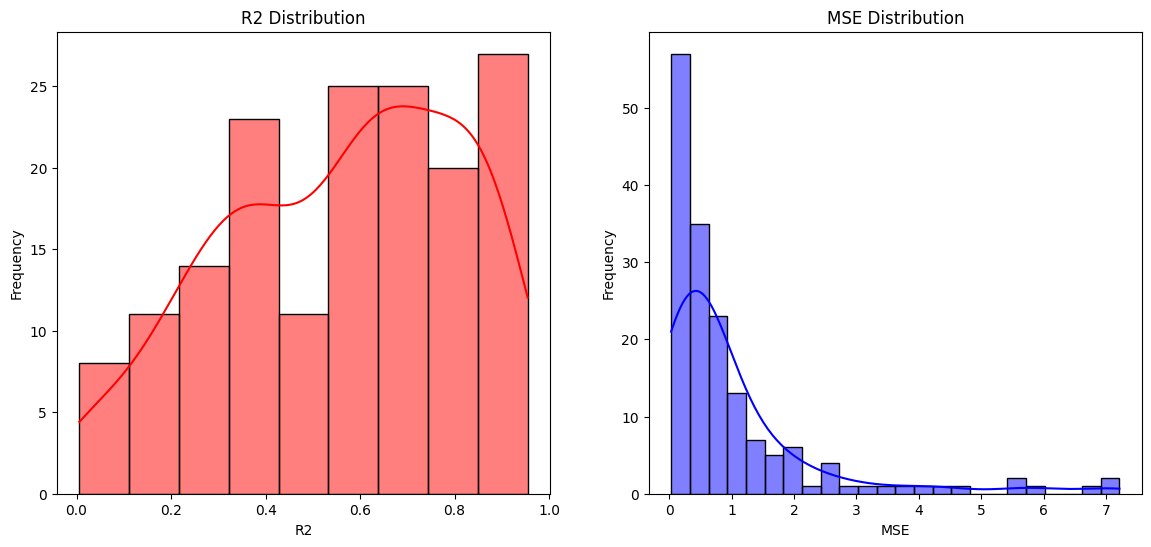

In [23]:
mse_values = [value['mse'] for value in results.values()]
r2_values = [value['r2'] for value in results.values()]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot R2 distribution
sns.histplot(r2_values, kde=True, ax=axes[0], color='red')
axes[0].set_title('R2 Distribution')
axes[0].set_xlabel('R2')
axes[0].set_ylabel('Frequency')

# Plot MSE distribution
sns.histplot(mse_values, kde=True, ax=axes[1], color='blue')
axes[1].set_title('MSE Distribution')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('Frequency')



In [31]:
import plotly.graph_objects as go

def plot_r2_mse_histogram(results, r2_color='red', mse_color='blue'):
    """
    Plots a histogram of R² and MSE values in descending order for each station.

    Parameters:
    results (dict): A dictionary where keys are station names and values are dictionaries
                    containing evaluation metrics including 'r2' and 'mse'.
                    Example: {'Station1': {'mse': 0.1, 'r2': 0.9}, 'Station2': {'mse': 0.2, 'r2': 0.85}, ...}
    """
    # Extract station names and corresponding R² and MSE values
    stations = list(results.keys())
    r2_values = [results[station]['r2'] for station in stations]
    mse_values = [results[station]['mse'] for station in stations]

    # Sort the stations, R² values, and MSE values in descending order of R² values
    sorted_stations_r2_mse = sorted(zip(stations, r2_values, mse_values), key=lambda x: x[1], reverse=True)
    sorted_stations, sorted_r2_values, sorted_mse_values = zip(*sorted_stations_r2_mse)

    # Create the plot
    fig = go.Figure()

    # Add a bar plot for R² values
    fig.add_trace(go.Bar(
        x=sorted_stations,
        y=sorted_r2_values,
        name='R²',
        marker=dict(color=r2_color),
        yaxis='y1'
    ))

    # Add a bar plot for MSE values
    fig.add_trace(go.Bar(
        x=sorted_stations,
        y=sorted_mse_values,
        name='MSE',
        marker=dict(color=mse_color),
        yaxis='y2'
    ))

    # Customize the layout
    fig.update_layout(
        title=dict(
            text='R² and MSE Values for each FLUXNET station',
            font=dict(color='black')
        ),
        xaxis=dict(
            title=dict(
                text='FLUXNET stations',
                font=dict(color='black')
            ),
            tickfont=dict(color='black'),
            linecolor='black',
            mirror=True
        ),
        yaxis=dict(
            title='R²',
            titlefont=dict(color=r2_color),
            tickfont=dict(color=r2_color),
            linecolor='black',
            mirror=True
        ),
        yaxis2=dict(
            title='MSE',
            titlefont=dict(color=mse_color),
            tickfont=dict(color=mse_color),
            overlaying='y',
            side='right',
            linecolor='black',
            mirror=True
        ),
        xaxis_tickangle=-45,
        template='plotly_white',
        legend=dict(
            x=0.1, y=1.1, orientation='h',
            font=dict(color='black')
        )
    )

    # Show the plot
    fig.show()

# Example usage


plot_r2_mse_histogram(results)

#### Experiment with valid stations treshold

In [10]:
igtp_list = ['ENF','GRA','DBF','CRO','WET','OSH','MF']
# Filter the DataFrame
cleaned_df = cleaned_df[cleaned_df['IGBP'].isin(igtp_list)]

In [11]:
ts_model_res = {}
IGBP_vareity = {}

for treshold in tqdm(np.arange(0.05, 1, 0.05)):

    valid_sations = {}
    for key in list(results):
        if results[key]['r2'] > treshold:
            valid_sations[key] = results[key]

    stations_to_keep = valid_sations.keys()
    filtered_df = cleaned_df[cleaned_df['station'].isin(stations_to_keep)]
    IGBP_vareity[treshold] = filtered_df.IGBP.value_counts().to_dict()


    mse, r2 = evaluate_station(filtered_df)
    ts_model_res[treshold] = {'mse': mse, 'r2': r2}
    print(treshold)

  0%|          | 0/19 [00:00<?, ?it/s]

0:	learn: 1.9503026	total: 17.6ms	remaining: 17.6s
100:	learn: 1.1422900	total: 2.14s	remaining: 19s
200:	learn: 0.9987639	total: 4.01s	remaining: 16s
300:	learn: 0.9095493	total: 5.9s	remaining: 13.7s
400:	learn: 0.8448606	total: 7.78s	remaining: 11.6s
500:	learn: 0.7911758	total: 9.69s	remaining: 9.65s
600:	learn: 0.7422627	total: 11.6s	remaining: 7.68s
700:	learn: 0.7023172	total: 13.4s	remaining: 5.73s
800:	learn: 0.6687659	total: 15.3s	remaining: 3.8s
900:	learn: 0.6359752	total: 17.1s	remaining: 1.88s


  5%|▌         | 1/19 [00:19<05:46, 19.25s/it]

999:	learn: 0.6107652	total: 19s	remaining: 0us
Mean Squared Error: 1.1939888296206358
R-squared: 0.7301039450533496
0.05
0:	learn: 1.9626986	total: 16ms	remaining: 16s
100:	learn: 1.1514759	total: 1.82s	remaining: 16.2s
200:	learn: 1.0033457	total: 3.6s	remaining: 14.3s
300:	learn: 0.9215005	total: 5.41s	remaining: 12.6s
400:	learn: 0.8622409	total: 7.19s	remaining: 10.7s
500:	learn: 0.8131849	total: 8.93s	remaining: 8.9s
600:	learn: 0.7718439	total: 10.7s	remaining: 7.1s
700:	learn: 0.7322017	total: 12.5s	remaining: 5.32s
800:	learn: 0.6956705	total: 14.2s	remaining: 3.54s
900:	learn: 0.6676214	total: 16.1s	remaining: 1.77s


 11%|█         | 2/19 [00:37<05:16, 18.60s/it]

999:	learn: 0.6394953	total: 17.9s	remaining: 0us
Mean Squared Error: 1.19884514596258
R-squared: 0.7290621163590341
0.1
0:	learn: 1.9663766	total: 15.4ms	remaining: 15.4s
100:	learn: 1.1467989	total: 1.78s	remaining: 15.9s
200:	learn: 0.9815730	total: 3.58s	remaining: 14.2s
300:	learn: 0.8826642	total: 5.36s	remaining: 12.4s
400:	learn: 0.8189915	total: 7.15s	remaining: 10.7s
500:	learn: 0.7696439	total: 8.99s	remaining: 8.96s
600:	learn: 0.7282306	total: 10.9s	remaining: 7.22s
700:	learn: 0.6886680	total: 12.7s	remaining: 5.41s
800:	learn: 0.6540782	total: 14.5s	remaining: 3.61s
900:	learn: 0.6229265	total: 16.4s	remaining: 1.8s


 16%|█▌        | 3/19 [00:55<04:55, 18.48s/it]

999:	learn: 0.5956719	total: 18.1s	remaining: 0us
Mean Squared Error: 1.2046992225009165
R-squared: 0.7269990710996748
0.15000000000000002
0:	learn: 1.9685445	total: 15.5ms	remaining: 15.5s
100:	learn: 1.1167461	total: 1.76s	remaining: 15.7s
200:	learn: 0.9661625	total: 3.49s	remaining: 13.9s
300:	learn: 0.8808402	total: 5.2s	remaining: 12.1s
400:	learn: 0.8161079	total: 6.91s	remaining: 10.3s
500:	learn: 0.7618400	total: 8.67s	remaining: 8.64s
600:	learn: 0.7153402	total: 10.4s	remaining: 6.92s
700:	learn: 0.6756377	total: 12.2s	remaining: 5.2s
800:	learn: 0.6414633	total: 13.9s	remaining: 3.46s
900:	learn: 0.6121801	total: 15.7s	remaining: 1.73s


 21%|██        | 4/19 [01:13<04:32, 18.14s/it]

999:	learn: 0.5849013	total: 17.4s	remaining: 0us
Mean Squared Error: 1.280486157140225
R-squared: 0.7163053427208311
0.2
0:	learn: 1.9791824	total: 15.5ms	remaining: 15.5s
100:	learn: 1.1215304	total: 1.79s	remaining: 15.9s
200:	learn: 0.9720628	total: 3.56s	remaining: 14.2s
300:	learn: 0.8808696	total: 5.34s	remaining: 12.4s
400:	learn: 0.8143453	total: 7.04s	remaining: 10.5s
500:	learn: 0.7594831	total: 8.78s	remaining: 8.75s
600:	learn: 0.7170363	total: 10.5s	remaining: 6.97s
700:	learn: 0.6797880	total: 12.2s	remaining: 5.21s
800:	learn: 0.6446228	total: 13.9s	remaining: 3.46s
900:	learn: 0.6109543	total: 15.7s	remaining: 1.72s


 26%|██▋       | 5/19 [01:30<04:11, 17.94s/it]

999:	learn: 0.5837978	total: 17.4s	remaining: 0us
Mean Squared Error: 1.239753817316237
R-squared: 0.7272360943579794
0.25
0:	learn: 1.9798038	total: 14.8ms	remaining: 14.8s
100:	learn: 1.0658529	total: 1.72s	remaining: 15.3s
200:	learn: 0.9219224	total: 3.4s	remaining: 13.5s
300:	learn: 0.8285402	total: 5.1s	remaining: 11.9s
400:	learn: 0.7672586	total: 6.8s	remaining: 10.2s
500:	learn: 0.7194488	total: 8.5s	remaining: 8.46s
600:	learn: 0.6757690	total: 10.2s	remaining: 6.75s
700:	learn: 0.6390228	total: 11.9s	remaining: 5.05s
800:	learn: 0.6048665	total: 13.6s	remaining: 3.37s
900:	learn: 0.5745626	total: 15.3s	remaining: 1.68s


 32%|███▏      | 6/19 [01:48<03:49, 17.68s/it]

999:	learn: 0.5463290	total: 17s	remaining: 0us
Mean Squared Error: 1.1130260528570248
R-squared: 0.7538903285240895
0.3
0:	learn: 2.0189696	total: 14.6ms	remaining: 14.6s
100:	learn: 1.0499910	total: 1.72s	remaining: 15.4s
200:	learn: 0.8938788	total: 3.39s	remaining: 13.5s
300:	learn: 0.8001400	total: 5.08s	remaining: 11.8s
400:	learn: 0.7319888	total: 6.76s	remaining: 10.1s
500:	learn: 0.6793457	total: 8.44s	remaining: 8.41s
600:	learn: 0.6363134	total: 10.1s	remaining: 6.71s
700:	learn: 0.5992792	total: 11.8s	remaining: 5.03s
800:	learn: 0.5642051	total: 13.4s	remaining: 3.33s
900:	learn: 0.5360738	total: 15.1s	remaining: 1.65s


 37%|███▋      | 7/19 [02:04<03:28, 17.41s/it]

999:	learn: 0.5065174	total: 16.7s	remaining: 0us
Mean Squared Error: 0.9977053317902598
R-squared: 0.7669488323178125
0.35000000000000003
0:	learn: 2.0535209	total: 14.1ms	remaining: 14.1s
100:	learn: 1.0479087	total: 1.66s	remaining: 14.8s
200:	learn: 0.8788131	total: 3.31s	remaining: 13.1s
300:	learn: 0.7860840	total: 4.96s	remaining: 11.5s
400:	learn: 0.7227313	total: 6.6s	remaining: 9.86s
500:	learn: 0.6720463	total: 8.26s	remaining: 8.22s
600:	learn: 0.6292741	total: 9.9s	remaining: 6.57s
700:	learn: 0.5928445	total: 11.6s	remaining: 4.93s
800:	learn: 0.5582725	total: 13.2s	remaining: 3.28s
900:	learn: 0.5286141	total: 14.8s	remaining: 1.63s


 42%|████▏     | 8/19 [02:21<03:09, 17.18s/it]

999:	learn: 0.5027437	total: 16.5s	remaining: 0us
Mean Squared Error: 0.8747852015821742
R-squared: 0.8026505506379837
0.4
0:	learn: 1.9953011	total: 14.6ms	remaining: 14.6s
100:	learn: 0.9514631	total: 1.68s	remaining: 15s
200:	learn: 0.7951289	total: 3.29s	remaining: 13.1s
300:	learn: 0.7034203	total: 4.95s	remaining: 11.5s
400:	learn: 0.6360909	total: 6.54s	remaining: 9.78s
500:	learn: 0.5865046	total: 8.17s	remaining: 8.14s
600:	learn: 0.5444331	total: 9.76s	remaining: 6.48s
700:	learn: 0.5081282	total: 11.4s	remaining: 4.86s
800:	learn: 0.4776111	total: 13s	remaining: 3.23s
900:	learn: 0.4493166	total: 14.6s	remaining: 1.61s


 47%|████▋     | 9/19 [02:38<02:49, 16.95s/it]

999:	learn: 0.4253980	total: 16.2s	remaining: 0us
Mean Squared Error: 0.919401135406148
R-squared: 0.8036803554811841
0.45
0:	learn: 2.0306805	total: 13.1ms	remaining: 13.1s
100:	learn: 0.9529127	total: 1.62s	remaining: 14.4s
200:	learn: 0.8118968	total: 3.21s	remaining: 12.8s
300:	learn: 0.7155230	total: 4.85s	remaining: 11.3s
400:	learn: 0.6450204	total: 6.46s	remaining: 9.65s
500:	learn: 0.5898194	total: 8.11s	remaining: 8.08s
600:	learn: 0.5470862	total: 9.73s	remaining: 6.46s
700:	learn: 0.5080098	total: 11.3s	remaining: 4.83s
800:	learn: 0.4750477	total: 12.9s	remaining: 3.21s
900:	learn: 0.4450809	total: 14.5s	remaining: 1.6s


 53%|█████▎    | 10/19 [02:54<02:30, 16.74s/it]

999:	learn: 0.4209750	total: 16.1s	remaining: 0us
Mean Squared Error: 0.8964687445448299
R-squared: 0.7977988209761613
0.5
0:	learn: 2.0320566	total: 13.8ms	remaining: 13.8s
100:	learn: 0.9260021	total: 1.64s	remaining: 14.6s
200:	learn: 0.7741592	total: 3.21s	remaining: 12.8s
300:	learn: 0.6852695	total: 4.8s	remaining: 11.1s
400:	learn: 0.6205405	total: 6.36s	remaining: 9.51s
500:	learn: 0.5655990	total: 8s	remaining: 7.97s
600:	learn: 0.5212429	total: 9.6s	remaining: 6.37s
700:	learn: 0.4827160	total: 11.2s	remaining: 4.78s
800:	learn: 0.4506917	total: 12.7s	remaining: 3.16s
900:	learn: 0.4239476	total: 14.3s	remaining: 1.57s


 58%|█████▊    | 11/19 [03:10<02:12, 16.54s/it]

999:	learn: 0.3977971	total: 15.9s	remaining: 0us
Mean Squared Error: 0.9015684296906137
R-squared: 0.8206920002268354
0.55
0:	learn: 2.1019677	total: 13.9ms	remaining: 13.9s
100:	learn: 0.9241391	total: 1.61s	remaining: 14.4s
200:	learn: 0.7772344	total: 3.15s	remaining: 12.5s
300:	learn: 0.6809116	total: 4.71s	remaining: 10.9s
400:	learn: 0.6108101	total: 6.25s	remaining: 9.34s
500:	learn: 0.5562696	total: 7.82s	remaining: 7.79s
600:	learn: 0.5134057	total: 9.41s	remaining: 6.25s
700:	learn: 0.4740538	total: 11s	remaining: 4.7s
800:	learn: 0.4383223	total: 12.6s	remaining: 3.12s
900:	learn: 0.4094887	total: 14.1s	remaining: 1.55s


 63%|██████▎   | 12/19 [03:26<01:54, 16.33s/it]

999:	learn: 0.3855411	total: 15.6s	remaining: 0us
Mean Squared Error: 0.789452635540347
R-squared: 0.8296598401717948
0.6000000000000001
0:	learn: 2.1705156	total: 13ms	remaining: 13s
100:	learn: 0.8975035	total: 1.59s	remaining: 14.2s
200:	learn: 0.7239045	total: 3.13s	remaining: 12.4s
300:	learn: 0.6265760	total: 4.67s	remaining: 10.8s
400:	learn: 0.5609691	total: 6.19s	remaining: 9.24s
500:	learn: 0.5049469	total: 7.72s	remaining: 7.69s
600:	learn: 0.4610378	total: 9.23s	remaining: 6.13s
700:	learn: 0.4218130	total: 10.8s	remaining: 4.62s
800:	learn: 0.3888766	total: 12.3s	remaining: 3.06s
900:	learn: 0.3614128	total: 13.9s	remaining: 1.53s


 68%|██████▊   | 13/19 [03:41<01:36, 16.10s/it]

999:	learn: 0.3391039	total: 15.4s	remaining: 0us
Mean Squared Error: 0.6354248698142186
R-squared: 0.8674271137701833
0.6500000000000001
0:	learn: 2.2326398	total: 12.2ms	remaining: 12.2s
100:	learn: 0.8521191	total: 1.54s	remaining: 13.7s
200:	learn: 0.6912394	total: 3s	remaining: 11.9s
300:	learn: 0.5943261	total: 4.56s	remaining: 10.6s
400:	learn: 0.5263447	total: 6.13s	remaining: 9.16s
500:	learn: 0.4724933	total: 7.81s	remaining: 7.78s
600:	learn: 0.4287429	total: 9.51s	remaining: 6.31s
700:	learn: 0.3921091	total: 11.3s	remaining: 4.81s
800:	learn: 0.3587230	total: 13s	remaining: 3.24s
900:	learn: 0.3328532	total: 14.7s	remaining: 1.62s


 74%|███████▎  | 14/19 [03:58<01:21, 16.24s/it]

999:	learn: 0.3078839	total: 16.4s	remaining: 0us
Mean Squared Error: 0.9134390825617508
R-squared: 0.8447011588095003
0.7000000000000001
0:	learn: 2.3446504	total: 13.9ms	remaining: 13.9s
100:	learn: 0.8597403	total: 1.74s	remaining: 15.5s
200:	learn: 0.6860139	total: 3.42s	remaining: 13.6s
300:	learn: 0.5783304	total: 5.14s	remaining: 11.9s
400:	learn: 0.5034524	total: 6.83s	remaining: 10.2s
500:	learn: 0.4486755	total: 8.69s	remaining: 8.65s
600:	learn: 0.4067892	total: 10.4s	remaining: 6.87s
700:	learn: 0.3665546	total: 12.1s	remaining: 5.15s
800:	learn: 0.3344462	total: 13.7s	remaining: 3.41s
900:	learn: 0.3066104	total: 15.4s	remaining: 1.69s


 79%|███████▉  | 15/19 [04:15<01:06, 16.55s/it]

999:	learn: 0.2826002	total: 17.1s	remaining: 0us
Mean Squared Error: 0.8027592435159461
R-squared: 0.879107411606112
0.7500000000000001
0:	learn: 2.4857577	total: 13.5ms	remaining: 13.5s
100:	learn: 0.8399732	total: 1.65s	remaining: 14.7s
200:	learn: 0.6749997	total: 3.29s	remaining: 13.1s
300:	learn: 0.5715649	total: 4.95s	remaining: 11.5s
400:	learn: 0.5001117	total: 6.49s	remaining: 9.7s
500:	learn: 0.4433104	total: 7.95s	remaining: 7.92s
600:	learn: 0.3957222	total: 9.53s	remaining: 6.33s
700:	learn: 0.3539965	total: 11.1s	remaining: 4.74s
800:	learn: 0.3174438	total: 12.6s	remaining: 3.14s
900:	learn: 0.2865366	total: 14.2s	remaining: 1.56s


 84%|████████▍ | 16/19 [04:31<00:49, 16.37s/it]

999:	learn: 0.2618143	total: 15.7s	remaining: 0us
Mean Squared Error: 0.7450909600585695
R-squared: 0.8956962039898476
0.8
0:	learn: 2.5901254	total: 12.2ms	remaining: 12.2s
100:	learn: 0.7486054	total: 1.51s	remaining: 13.5s
200:	learn: 0.5682620	total: 2.95s	remaining: 11.7s
300:	learn: 0.4608607	total: 4.56s	remaining: 10.6s
400:	learn: 0.3826309	total: 5.99s	remaining: 8.95s
500:	learn: 0.3247453	total: 7.55s	remaining: 7.52s
600:	learn: 0.2787415	total: 8.98s	remaining: 5.96s
700:	learn: 0.2422446	total: 10.5s	remaining: 4.5s
800:	learn: 0.2140172	total: 12.1s	remaining: 3s
900:	learn: 0.1911528	total: 13.6s	remaining: 1.49s


 89%|████████▉ | 17/19 [04:46<00:32, 16.03s/it]

999:	learn: 0.1725812	total: 15s	remaining: 0us
Mean Squared Error: 0.9938871108407062
R-squared: 0.8622605112202435
0.8500000000000001
0:	learn: 3.0330769	total: 12.4ms	remaining: 12.4s
100:	learn: 0.5417557	total: 1.47s	remaining: 13.1s
200:	learn: 0.3113156	total: 2.9s	remaining: 11.5s
300:	learn: 0.1884798	total: 4.31s	remaining: 10s
400:	learn: 0.1284762	total: 5.83s	remaining: 8.7s
500:	learn: 0.0859827	total: 7.24s	remaining: 7.21s
600:	learn: 0.0620692	total: 8.77s	remaining: 5.82s
700:	learn: 0.0462079	total: 10.2s	remaining: 4.36s
800:	learn: 0.0340778	total: 11.8s	remaining: 2.92s
900:	learn: 0.0246768	total: 13.3s	remaining: 1.46s


 95%|█████████▍| 18/19 [05:01<00:15, 15.69s/it]

999:	learn: 0.0194971	total: 14.7s	remaining: 0us
Mean Squared Error: 1.2193367232334786
R-squared: 0.8832686420525755
0.9000000000000001
0:	learn: 3.8700625	total: 1.08ms	remaining: 1.07s
100:	learn: 0.1269621	total: 88ms	remaining: 784ms
200:	learn: 0.0174791	total: 158ms	remaining: 626ms
300:	learn: 0.0031986	total: 224ms	remaining: 519ms
400:	learn: 0.0007463	total: 288ms	remaining: 431ms
500:	learn: 0.0001837	total: 356ms	remaining: 354ms
600:	learn: 0.0000468	total: 424ms	remaining: 281ms
700:	learn: 0.0000131	total: 490ms	remaining: 209ms


100%|██████████| 19/19 [05:02<00:00, 15.93s/it]

800:	learn: 0.0000036	total: 560ms	remaining: 139ms
900:	learn: 0.0000011	total: 630ms	remaining: 69.2ms
999:	learn: 0.0000003	total: 692ms	remaining: 0us
Mean Squared Error: 0.8291344225303632
R-squared: 0.9546361874372638
0.9500000000000001


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_ecosystem_data(data, color_mapping, ts_model_res):
    """
    Plots a stacked bar chart for ecosystem data and a line plot for R2 scores using Plotly.

    Parameters:
    data (dict): A dictionary where keys are thresholds and values are dictionaries
                 of ecosystem counts.
    color_mapping (dict): A dictionary mapping ecosystem names to color codes.
    ts_model_res (dict): A dictionary where keys are parameters and values are dictionaries
                         containing 'r2' scores.
    """
    # Extract thresholds and ecosystems
    thresholds = list(data.keys())
    ecosystems = list({eco for d in data.values() for eco in d.keys()})

    # Prepare data for plotting
    plot_data = {eco: [data[t].get(eco, 0) for t in thresholds] for eco in ecosystems}

    # Extract keys and R2 values for the line plot
    keys = list(ts_model_res.keys())
    r2_values = [ts_model_res[key]['r2'] for key in keys]

    # Create the subplot figure with 1 row and 2 columns
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Ecosystem distribution in data', 'R² for treshold value'))

    # Add traces for each ecosystem (stacked bar chart)
    for eco, values in plot_data.items():
        fig.add_trace(go.Bar(
            x=thresholds,
            y=values,
            name=eco,
            marker_color=color_mapping.get(eco, '#000000')  # Default to black if not found
        ), row=1, col=1)

    # Add the line plot for R2 scores
    fig.add_trace(go.Scatter(
        x=keys,
        y=r2_values,
        mode='lines+markers',
        name='R2 Score',
        marker=dict(color='blue')
    ), row=1, col=2)

    # Update layout for better visualization
    fig.update_layout(
        barmode='stack',
        xaxis=dict(
            title='Threshold',
            showgrid=True,  # Show gridlines on x-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        yaxis=dict(
            title='Total Number of measurements',
            showgrid=True,  # Show gridlines on y-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        xaxis2=dict(
            title='Threshold',
            showgrid=True,  # Show gridlines on x-axis
            gridcolor='lightgrey',  # Color of the gridlines
            dtick=0.2  # More vertical grid line
        ),
        yaxis2=dict(
            title='R² Score',
            showgrid=True,  # Show gridlines on y-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        legend=dict(
            title='',
            orientation='h',  # Horizontal legend
            yanchor='bottom',
            y=-0.3,  # Position legend below the plots
            xanchor='center',
            x=0.5
        ),
        plot_bgcolor='white',  # Set the plot background color to white
        paper_bgcolor='white'  # Set the paper background color to white
    )

    # Show the plot
    fig.show()



color_mapping = {
    'ENF': '#008001',
    'GRA': '#FF9900',
    'DBF': '#99FF99', 
    'CRO': '#FFFF00',
    'WET': '#006699', 
    'OSH': '#FFCC99', 
    'MF': '#339966', 
    'EBF': '#02FF00',
    'CSH': '#993365',
}


plot_ecosystem_data(IGBP_vareity, color_mapping, ts_model_res)

In [77]:
# valid_stations_list = 
for key in list(results):
    if results[key]['r2'] > 0.3:
        valid_sations[key] = results[key]

valid_stations_list =  list(valid_sations.keys())

Conclusion: treshhold = 0.3 is optimal number. If we will use only stations that have R2 bigger than 0.3 on on eigenvalue modeling, we will have r2 > 0.76 on overall modelling (Using baseline model). Also such threshold keeps variety in IGBP ecosystems it training data. 

### SHAP

In [4]:
data_preprocessing = DataPreprocessing(r'C:\Univercity\Skoltech\NEE_2.0\forest_meteo_gpp_nee_2024.csv', 
                                  r'C:\Univercity\Skoltech\NEE_2.0\NO_FOREST_meteo_gpp_nee_2024.csv')

data_preprocessing.load_and_clean_data()
data_preprocessing.drop_rows_with_value_counts()

corr_features = data_preprocessing.correlation(data_preprocessing.df.drop(['NEE', 'GPP'], axis=1), 0.6)
data_preprocessing.df.drop(corr_features, axis=1, inplace=True)

cleaned_df, df_date, category = data_preprocessing.mean_daily_data_by_month()
cleaned_df = cleaned_df.interpolate()

In [5]:
features_to_drop = ['Year','Month', 'station', 'lon', 'lat', 'NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
# model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

0:	learn: 1.9555124	total: 198ms	remaining: 3m 17s
100:	learn: 1.0884509	total: 6.29s	remaining: 56s
200:	learn: 0.9409877	total: 11.6s	remaining: 46.2s
300:	learn: 0.8528533	total: 16.3s	remaining: 38s
400:	learn: 0.7912653	total: 21.2s	remaining: 31.6s
500:	learn: 0.7354657	total: 25.8s	remaining: 25.7s
600:	learn: 0.6894081	total: 30.6s	remaining: 20.3s
700:	learn: 0.6507482	total: 35.3s	remaining: 15.1s
800:	learn: 0.6156772	total: 40.1s	remaining: 9.97s
900:	learn: 0.5840549	total: 45s	remaining: 4.95s
999:	learn: 0.5573043	total: 49.9s	remaining: 0us
Mean Squared Error: 1.0551811405782516
R-squared: 0.7511225755220825


#### Simple feature importance

In [69]:
# Calculate feature importance
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train_scaled.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Dictionary to store R-squared values
r2_dict = {}

# Iteratively train the model with increasing number of top features
for i in tqdm(range(1, len(feature_importance_df) + 1)):
    top_features = feature_importance_df['Feature'].iloc[:i].tolist()
    
    X_train_top = X_train_scaled[top_features]
    X_test_top = X_test_scaled[top_features]
    
    categorical_features = ['IGBP']
    train_pool_top = Pool(data=X_train_top, label=y_train, cat_features=[f for f in top_features if f in categorical_features])
    test_pool_top = Pool(data=X_test_top, label=y_test, cat_features=[f for f in top_features if f in categorical_features])
    
    model_top = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
    model_top.fit(train_pool_top)
    
    predictions_top = model_top.predict(test_pool_top)
    
    r2_top = r2_score(y_test, predictions_top)
    r2_dict[i] = r2_top




  0%|          | 0/22 [00:00<?, ?it/s]

0:	learn: 1.9644300	total: 1.91ms	remaining: 1.91s
100:	learn: 1.5955181	total: 214ms	remaining: 1.9s
200:	learn: 1.5856451	total: 370ms	remaining: 1.47s
300:	learn: 1.5812611	total: 523ms	remaining: 1.21s
400:	learn: 1.5791903	total: 673ms	remaining: 1s
500:	learn: 1.5781457	total: 824ms	remaining: 821ms
600:	learn: 1.5775960	total: 975ms	remaining: 648ms
700:	learn: 1.5772496	total: 1.13s	remaining: 480ms
800:	learn: 1.5770198	total: 1.28s	remaining: 317ms


  5%|▍         | 1/22 [00:01<00:34,  1.66s/it]

900:	learn: 1.5768689	total: 1.43s	remaining: 157ms
999:	learn: 1.5767727	total: 1.58s	remaining: 0us
0:	learn: 1.9661598	total: 13.7ms	remaining: 13.7s
100:	learn: 1.4979125	total: 1.69s	remaining: 15s
200:	learn: 1.4711773	total: 3.33s	remaining: 13.2s
300:	learn: 1.4553588	total: 4.98s	remaining: 11.6s
400:	learn: 1.4406375	total: 6.61s	remaining: 9.88s
500:	learn: 1.4278966	total: 8.29s	remaining: 8.26s
600:	learn: 1.4172517	total: 9.92s	remaining: 6.59s
700:	learn: 1.4069254	total: 11.6s	remaining: 4.96s
800:	learn: 1.3975199	total: 13.3s	remaining: 3.31s
900:	learn: 1.3889253	total: 15s	remaining: 1.65s


  9%|▉         | 2/22 [00:18<03:30, 10.53s/it]

999:	learn: 1.3811775	total: 16.6s	remaining: 0us
0:	learn: 1.9555098	total: 14.3ms	remaining: 14.3s
100:	learn: 1.3006600	total: 1.67s	remaining: 14.8s
200:	learn: 1.1956857	total: 3.35s	remaining: 13.3s
300:	learn: 1.1359349	total: 5.07s	remaining: 11.8s
400:	learn: 1.0972151	total: 6.85s	remaining: 10.2s
500:	learn: 1.0609042	total: 8.65s	remaining: 8.62s
600:	learn: 1.0325045	total: 10.4s	remaining: 6.91s
700:	learn: 1.0091182	total: 12.1s	remaining: 5.17s
800:	learn: 0.9875289	total: 13.8s	remaining: 3.43s
900:	learn: 0.9701507	total: 15.5s	remaining: 1.7s


 14%|█▎        | 3/22 [00:35<04:18, 13.62s/it]

999:	learn: 0.9553663	total: 17.2s	remaining: 0us
0:	learn: 1.9571265	total: 15.5ms	remaining: 15.5s
100:	learn: 1.1948714	total: 1.79s	remaining: 16s
200:	learn: 1.0923884	total: 3.56s	remaining: 14.2s
300:	learn: 1.0297386	total: 5.31s	remaining: 12.3s
400:	learn: 0.9893889	total: 7.01s	remaining: 10.5s
500:	learn: 0.9570630	total: 8.77s	remaining: 8.74s
600:	learn: 0.9251374	total: 10.5s	remaining: 6.94s
700:	learn: 0.9004194	total: 12.3s	remaining: 5.23s
800:	learn: 0.8792512	total: 14.1s	remaining: 3.5s
900:	learn: 0.8600749	total: 15.9s	remaining: 1.74s


 18%|█▊        | 4/22 [00:53<04:34, 15.23s/it]

999:	learn: 0.8415359	total: 17.6s	remaining: 0us
0:	learn: 1.9591517	total: 14.8ms	remaining: 14.8s
100:	learn: 1.1685512	total: 1.79s	remaining: 15.9s
200:	learn: 1.0609389	total: 3.48s	remaining: 13.9s
300:	learn: 1.0022336	total: 5.28s	remaining: 12.3s
400:	learn: 0.9541664	total: 7.03s	remaining: 10.5s
500:	learn: 0.9142337	total: 8.78s	remaining: 8.74s
600:	learn: 0.8831035	total: 10.5s	remaining: 6.97s
700:	learn: 0.8559788	total: 12.3s	remaining: 5.23s
800:	learn: 0.8313162	total: 14s	remaining: 3.48s
900:	learn: 0.8102090	total: 15.8s	remaining: 1.74s


 23%|██▎       | 5/22 [01:11<04:33, 16.11s/it]

999:	learn: 0.7909097	total: 17.5s	remaining: 0us
0:	learn: 1.9526721	total: 15.2ms	remaining: 15.2s
100:	learn: 1.1381823	total: 1.87s	remaining: 16.7s
200:	learn: 1.0315305	total: 3.65s	remaining: 14.5s
300:	learn: 0.9737979	total: 5.43s	remaining: 12.6s
400:	learn: 0.9286082	total: 7.21s	remaining: 10.8s
500:	learn: 0.8890231	total: 9.08s	remaining: 9.05s
600:	learn: 0.8555085	total: 10.8s	remaining: 7.19s
700:	learn: 0.8264156	total: 12.7s	remaining: 5.41s
800:	learn: 0.8022273	total: 14.5s	remaining: 3.6s
900:	learn: 0.7771718	total: 16.3s	remaining: 1.79s


 27%|██▋       | 6/22 [01:29<04:29, 16.83s/it]

999:	learn: 0.7550694	total: 18.1s	remaining: 0us
0:	learn: 1.9521792	total: 16ms	remaining: 16s
100:	learn: 1.1239013	total: 1.88s	remaining: 16.7s
200:	learn: 1.0152630	total: 3.77s	remaining: 15s
300:	learn: 0.9451970	total: 5.6s	remaining: 13s
400:	learn: 0.8953289	total: 7.41s	remaining: 11.1s
500:	learn: 0.8536576	total: 9.3s	remaining: 9.27s
600:	learn: 0.8161402	total: 11.2s	remaining: 7.42s
700:	learn: 0.7863713	total: 13.1s	remaining: 5.6s
800:	learn: 0.7584432	total: 15s	remaining: 3.73s
900:	learn: 0.7339651	total: 16.9s	remaining: 1.85s


 32%|███▏      | 7/22 [01:48<04:21, 17.46s/it]

999:	learn: 0.7121307	total: 18.6s	remaining: 0us
0:	learn: 1.9561019	total: 16.4ms	remaining: 16.4s
100:	learn: 1.1211044	total: 1.86s	remaining: 16.5s
200:	learn: 1.0082151	total: 3.74s	remaining: 14.9s
300:	learn: 0.9458822	total: 5.69s	remaining: 13.2s
400:	learn: 0.8934100	total: 7.57s	remaining: 11.3s
500:	learn: 0.8507549	total: 9.49s	remaining: 9.45s
600:	learn: 0.8161280	total: 11.3s	remaining: 7.5s
700:	learn: 0.7847622	total: 13.2s	remaining: 5.62s
800:	learn: 0.7547057	total: 15s	remaining: 3.73s
900:	learn: 0.7304639	total: 16.9s	remaining: 1.85s


 36%|███▋      | 8/22 [02:06<04:10, 17.91s/it]

999:	learn: 0.7095674	total: 18.8s	remaining: 0us
0:	learn: 1.9574797	total: 16.2ms	remaining: 16.1s
100:	learn: 1.1156697	total: 1.92s	remaining: 17.1s
200:	learn: 1.0004891	total: 3.77s	remaining: 15s
300:	learn: 0.9269498	total: 5.66s	remaining: 13.2s
400:	learn: 0.8726503	total: 7.58s	remaining: 11.3s
500:	learn: 0.8312752	total: 9.55s	remaining: 9.51s
600:	learn: 0.7948972	total: 11.4s	remaining: 7.58s
700:	learn: 0.7659212	total: 13.3s	remaining: 5.66s
800:	learn: 0.7361424	total: 15.2s	remaining: 3.77s
900:	learn: 0.7099858	total: 17s	remaining: 1.87s


 41%|████      | 9/22 [02:25<03:57, 18.24s/it]

999:	learn: 0.6866453	total: 18.8s	remaining: 0us
0:	learn: 1.9544640	total: 16ms	remaining: 15.9s
100:	learn: 1.1032844	total: 1.84s	remaining: 16.4s
200:	learn: 0.9808418	total: 3.67s	remaining: 14.6s
300:	learn: 0.9084790	total: 5.51s	remaining: 12.8s
400:	learn: 0.8559347	total: 7.32s	remaining: 10.9s
500:	learn: 0.8107357	total: 9.22s	remaining: 9.18s
600:	learn: 0.7758786	total: 11.1s	remaining: 7.36s
700:	learn: 0.7414238	total: 13s	remaining: 5.54s
800:	learn: 0.7101637	total: 14.9s	remaining: 3.69s
900:	learn: 0.6818991	total: 16.7s	remaining: 1.84s


 45%|████▌     | 10/22 [02:44<03:40, 18.37s/it]

999:	learn: 0.6598681	total: 18.5s	remaining: 0us
0:	learn: 1.9535095	total: 15.4ms	remaining: 15.4s
100:	learn: 1.1018444	total: 1.92s	remaining: 17.1s
200:	learn: 0.9759823	total: 3.82s	remaining: 15.2s
300:	learn: 0.9066997	total: 5.67s	remaining: 13.2s
400:	learn: 0.8534712	total: 7.53s	remaining: 11.2s
500:	learn: 0.8041044	total: 9.39s	remaining: 9.36s
600:	learn: 0.7626185	total: 11.2s	remaining: 7.46s
700:	learn: 0.7298093	total: 13.2s	remaining: 5.62s
800:	learn: 0.6992643	total: 15.1s	remaining: 3.74s
900:	learn: 0.6719132	total: 16.9s	remaining: 1.86s


 50%|█████     | 11/22 [03:03<03:23, 18.53s/it]

999:	learn: 0.6446216	total: 18.8s	remaining: 0us
0:	learn: 1.9526006	total: 16.1ms	remaining: 16.1s
100:	learn: 1.0959275	total: 1.88s	remaining: 16.8s
200:	learn: 0.9586053	total: 3.78s	remaining: 15s
300:	learn: 0.8830655	total: 5.72s	remaining: 13.3s
400:	learn: 0.8264626	total: 7.6s	remaining: 11.4s
500:	learn: 0.7799744	total: 9.51s	remaining: 9.47s
600:	learn: 0.7399455	total: 11.5s	remaining: 7.6s
700:	learn: 0.7087587	total: 13.4s	remaining: 5.73s
800:	learn: 0.6789922	total: 15.4s	remaining: 3.82s
900:	learn: 0.6525130	total: 17.2s	remaining: 1.9s


 55%|█████▍    | 12/22 [03:22<03:07, 18.73s/it]

999:	learn: 0.6273490	total: 19.1s	remaining: 0us
0:	learn: 1.9585963	total: 16.5ms	remaining: 16.5s
100:	learn: 1.0925957	total: 1.9s	remaining: 16.9s
200:	learn: 0.9667256	total: 3.75s	remaining: 14.9s
300:	learn: 0.8828369	total: 5.71s	remaining: 13.3s
400:	learn: 0.8252148	total: 7.59s	remaining: 11.3s
500:	learn: 0.7769920	total: 9.54s	remaining: 9.5s
600:	learn: 0.7365413	total: 11.5s	remaining: 7.64s
700:	learn: 0.7009909	total: 13.5s	remaining: 5.76s
800:	learn: 0.6734004	total: 15.5s	remaining: 3.84s
900:	learn: 0.6465349	total: 17.5s	remaining: 1.92s


 59%|█████▉    | 13/22 [03:42<02:50, 18.96s/it]

999:	learn: 0.6214569	total: 19.3s	remaining: 0us
0:	learn: 1.9543959	total: 16.2ms	remaining: 16.2s
100:	learn: 1.1005250	total: 1.93s	remaining: 17.2s
200:	learn: 0.9648904	total: 3.83s	remaining: 15.2s
300:	learn: 0.8846916	total: 5.77s	remaining: 13.4s
400:	learn: 0.8240542	total: 7.72s	remaining: 11.5s
500:	learn: 0.7728028	total: 9.61s	remaining: 9.57s
600:	learn: 0.7297169	total: 11.5s	remaining: 7.66s
700:	learn: 0.6931787	total: 13.5s	remaining: 5.76s
800:	learn: 0.6620967	total: 15.4s	remaining: 3.83s
900:	learn: 0.6334916	total: 17.4s	remaining: 1.91s


 64%|██████▎   | 14/22 [04:01<02:32, 19.10s/it]

999:	learn: 0.6090868	total: 19.3s	remaining: 0us
0:	learn: 1.9553238	total: 17.6ms	remaining: 17.6s
100:	learn: 1.0994461	total: 1.96s	remaining: 17.4s
200:	learn: 0.9587869	total: 3.9s	remaining: 15.5s
300:	learn: 0.8823983	total: 5.84s	remaining: 13.6s
400:	learn: 0.8172759	total: 7.82s	remaining: 11.7s
500:	learn: 0.7666177	total: 9.8s	remaining: 9.76s
600:	learn: 0.7235859	total: 11.7s	remaining: 7.78s
700:	learn: 0.6849560	total: 13.7s	remaining: 5.82s
800:	learn: 0.6520343	total: 15.6s	remaining: 3.88s
900:	learn: 0.6232126	total: 17.6s	remaining: 1.94s


 68%|██████▊   | 15/22 [04:21<02:15, 19.30s/it]

999:	learn: 0.5950563	total: 19.6s	remaining: 0us
0:	learn: 1.9540580	total: 16.6ms	remaining: 16.5s
100:	learn: 1.0856559	total: 1.95s	remaining: 17.4s
200:	learn: 0.9545598	total: 3.89s	remaining: 15.4s
300:	learn: 0.8727672	total: 5.9s	remaining: 13.7s
400:	learn: 0.8068499	total: 7.9s	remaining: 11.8s
500:	learn: 0.7551981	total: 9.85s	remaining: 9.81s
600:	learn: 0.7117479	total: 11.8s	remaining: 7.82s
700:	learn: 0.6753256	total: 13.7s	remaining: 5.85s
800:	learn: 0.6449478	total: 15.7s	remaining: 3.91s
900:	learn: 0.6175012	total: 17.7s	remaining: 1.95s


 73%|███████▎  | 16/22 [04:41<01:56, 19.44s/it]

999:	learn: 0.5919516	total: 19.6s	remaining: 0us
0:	learn: 1.9544939	total: 16.5ms	remaining: 16.5s
100:	learn: 1.0874024	total: 1.96s	remaining: 17.5s
200:	learn: 0.9491412	total: 3.93s	remaining: 15.6s
300:	learn: 0.8681770	total: 5.94s	remaining: 13.8s
400:	learn: 0.8064701	total: 7.85s	remaining: 11.7s
500:	learn: 0.7556113	total: 9.79s	remaining: 9.75s
600:	learn: 0.7118131	total: 11.8s	remaining: 7.83s
700:	learn: 0.6758342	total: 13.8s	remaining: 5.88s
800:	learn: 0.6423093	total: 15.7s	remaining: 3.91s
900:	learn: 0.6105409	total: 17.7s	remaining: 1.95s


 77%|███████▋  | 17/22 [05:00<01:37, 19.54s/it]

999:	learn: 0.5855899	total: 19.7s	remaining: 0us
0:	learn: 1.9545657	total: 16.3ms	remaining: 16.3s
100:	learn: 1.0866072	total: 1.92s	remaining: 17.1s
200:	learn: 0.9439547	total: 3.83s	remaining: 15.2s
300:	learn: 0.8592021	total: 5.77s	remaining: 13.4s
400:	learn: 0.7988558	total: 7.67s	remaining: 11.5s
500:	learn: 0.7470394	total: 9.6s	remaining: 9.56s
600:	learn: 0.7031171	total: 11.6s	remaining: 7.69s
700:	learn: 0.6667876	total: 13.5s	remaining: 5.78s
800:	learn: 0.6333980	total: 15.4s	remaining: 3.83s
900:	learn: 0.6039686	total: 17.3s	remaining: 1.91s


 82%|████████▏ | 18/22 [05:20<01:17, 19.48s/it]

999:	learn: 0.5789204	total: 19.2s	remaining: 0us
0:	learn: 1.9567400	total: 16.6ms	remaining: 16.5s
100:	learn: 1.0908044	total: 1.97s	remaining: 17.5s
200:	learn: 0.9444569	total: 3.94s	remaining: 15.7s
300:	learn: 0.8613124	total: 5.83s	remaining: 13.5s
400:	learn: 0.8013446	total: 7.71s	remaining: 11.5s
500:	learn: 0.7509706	total: 9.69s	remaining: 9.65s
600:	learn: 0.7046557	total: 11.6s	remaining: 7.68s
700:	learn: 0.6650033	total: 13.5s	remaining: 5.75s
800:	learn: 0.6330717	total: 15.4s	remaining: 3.82s
900:	learn: 0.6022243	total: 17.4s	remaining: 1.91s


 86%|████████▋ | 19/22 [05:39<00:58, 19.46s/it]

999:	learn: 0.5754930	total: 19.3s	remaining: 0us
0:	learn: 1.9593509	total: 17.5ms	remaining: 17.5s
100:	learn: 1.0906634	total: 1.95s	remaining: 17.3s
200:	learn: 0.9485139	total: 3.91s	remaining: 15.6s
300:	learn: 0.8588328	total: 5.89s	remaining: 13.7s
400:	learn: 0.7951579	total: 7.81s	remaining: 11.7s
500:	learn: 0.7456985	total: 9.73s	remaining: 9.69s
600:	learn: 0.6978994	total: 11.6s	remaining: 7.71s
700:	learn: 0.6595151	total: 13.6s	remaining: 5.78s
800:	learn: 0.6249809	total: 15.5s	remaining: 3.84s
900:	learn: 0.5935622	total: 17.5s	remaining: 1.92s


 91%|█████████ | 20/22 [05:59<00:38, 19.49s/it]

999:	learn: 0.5651622	total: 19.4s	remaining: 0us
0:	learn: 1.9568037	total: 16.8ms	remaining: 16.8s
100:	learn: 1.0923899	total: 1.95s	remaining: 17.4s
200:	learn: 0.9477992	total: 3.84s	remaining: 15.3s
300:	learn: 0.8575384	total: 5.82s	remaining: 13.5s
400:	learn: 0.7922260	total: 7.79s	remaining: 11.6s
500:	learn: 0.7371342	total: 9.75s	remaining: 9.71s
600:	learn: 0.6933033	total: 11.7s	remaining: 7.76s
700:	learn: 0.6543362	total: 13.6s	remaining: 5.8s
800:	learn: 0.6209827	total: 15.6s	remaining: 3.88s
900:	learn: 0.5915280	total: 17.6s	remaining: 1.94s


 95%|█████████▌| 21/22 [06:18<00:19, 19.54s/it]

999:	learn: 0.5649651	total: 19.5s	remaining: 0us
0:	learn: 1.9528609	total: 18.4ms	remaining: 18.4s
100:	learn: 1.0845482	total: 1.96s	remaining: 17.4s
200:	learn: 0.9383507	total: 3.95s	remaining: 15.7s
300:	learn: 0.8562390	total: 5.96s	remaining: 13.8s
400:	learn: 0.7924097	total: 7.89s	remaining: 11.8s
500:	learn: 0.7375972	total: 9.86s	remaining: 9.82s
600:	learn: 0.6936885	total: 11.8s	remaining: 7.83s
700:	learn: 0.6560013	total: 13.9s	remaining: 5.92s
800:	learn: 0.6233751	total: 15.9s	remaining: 3.94s
900:	learn: 0.5914965	total: 17.8s	remaining: 1.96s


100%|██████████| 22/22 [06:38<00:00, 18.12s/it]

999:	learn: 0.5647766	total: 19.7s	remaining: 0us


In [90]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_feature_importance_and_r2(model, train_pool, X_train_scaled, r2_dict):
    """
    Plots feature importances and R2 values side by side using Plotly.

    Parameters:
    model: The trained model object.
    train_pool: The training data pool used by the model.
    X_train_scaled: The scaled training data used by the model.
    r2_dict (dict): A dictionary where keys are parameters and values are R2 scores.
    """
    # Get feature importances
    feature_importances = model.get_feature_importance(train_pool)
    feature_names = X_train_scaled.columns

    # Create a DataFrame for plotting
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort the DataFrame by importance
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    # Extract keys and R2 values for the bar plot
    keys = list(r2_dict.keys())
    r2_values = list(r2_dict.values())

    # Calculate the height of the plot based on the number of features
    num_features = len(importance_df)
    plot_height = max(600, num_features * 20)  # Adjust the multiplier as needed

    # Create the subplot figure with 1 row and 2 columns
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Feature Importances', 'Stepwise Forward Selection'))

    # Add the bar plot for feature importances
    fig.add_trace(go.Bar(
        x=importance_df['Importance'],
        y=importance_df['Feature'],
        orientation='h',
        name='Feature Importance',
        marker_color='orange'
    ), row=1, col=1)

    # Add the bar plot for R2 values
    fig.add_trace(go.Bar(
        x=keys,
        y=r2_values,
        name='R² Value',
        marker_color='green'
    ), row=1, col=2)

    # Add a red arrow annotation above the tenth bar on the right plot
    if len(keys) >= 10:
        fig.add_annotation(
            x=keys[9],  # The x position of the tenth bar
            y=r2_values[9] + 0.05,  # Slightly above the tenth bar
            text='',  # No text, just an arrow
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor='red',
            ax=0,  # Arrow tail x position
            ay=-40,  # Arrow tail y position (negative value means above the point)
            xref='x2',  # Reference to the x-axis of the second plot
            yref='y2'   # Reference to the y-axis of the second plot
        )

    # Update layout for better visualization
    fig.update_layout(
        height=plot_height,
        width=1200,
        xaxis=dict(
            title='Importance',
            showgrid=True,  # Show gridlines on x-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        yaxis=dict(
            title='Feature',
            showgrid=True,  # Show gridlines on y-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        xaxis2=dict(
            title='Number of Features',
            showgrid=True,  # Show gridlines on x-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        yaxis2=dict(
            title='R² value',
            showgrid=True,  # Show gridlines on y-axis
            gridcolor='lightgrey'  # Color of the gridlines
        ),
        legend=dict(
            title='',
            orientation='h',  # Horizontal legend
            yanchor='bottom',
            y=-0.3,  # Position legend below the plots
            xanchor='center',
            x=0.5,
            font=dict(size=20)  # Increase the size of the legend text
        ),
        plot_bgcolor='white',  # Set the plot background color to white
        paper_bgcolor='white'  # Set the paper background color to white
    )

    # Show the plot
    fig.show()

# Example usage
# Assuming model, train_pool, X_train_scaled, and r2_dict are already defined
plot_feature_importance_and_r2(model, train_pool, X_train_scaled, r2_dict)

In [ ]:
l = [GPP, IGBP, ZOM, RHOA, PW, ALLSKY_SRF_ALB, TS_RANGE, CLRSKY_SRF_ALB, WS50M_MIN, ZENITH_LUMINANCE, EVPTRNS, GWETTOP, ALLSKY_NKT, WS50M_RANGE, TROPT, WD50M, CLOUD_OD, PRECTOTCORR, V50M, PRECSNOLAND, CLRSKY_DAYS, SLP]

In [16]:
top_features[:10]

['GPP',
 'IGBP',
 'Z0M',
 'RHOA',
 'PW',
 'ALLSKY_SRF_ALB',
 'TS_RANGE',
 'CLRSKY_SRF_ALB',
 'WS50M_MIN',
 'ZENITH_LUMINANCE']

In [17]:
valid_features = ['GPP', 'IGBP', 'Z0M', 'RHOA', 'PW', 'ALLSKY_SRF_ALB',
                   'TS_RANGE', 'CLRSKY_SRF_ALB', 'WS50M_MIN', 'ZENITH_LUMINANCE']

Conclusion: 10 features are enough, after this number results dont change much. 

#### SHAP plots

In [34]:
data_preprocessing = DataPreprocessing(r'../data/forest_meteo_gpp_nee_2024.csv', 
                                  r'../data/NO_FOREST_meteo_gpp_nee_2024.csv')

data_preprocessing.load_and_clean_data()
data_preprocessing.drop_rows_with_value_counts()

corr_features = data_preprocessing.correlation(data_preprocessing.df.drop(['NEE', 'GPP', 'Date', 'station', 'IGBP'], axis=1), 0.6)
data_preprocessing.df.drop(corr_features, axis=1, inplace=True)

cleaned_df, df_date, category = data_preprocessing.mean_daily_data_by_month()
cleaned_df = cleaned_df.interpolate()

valid_features = ['GPP', 'IGBP', 'Z0M', 'RHOA', 'PW', 'ALLSKY_SRF_ALB',
                   'TS_RANGE', 'CLRSKY_SRF_ALB', 'WS50M_MIN', 'ZENITH_LUMINANCE']
columns_to_select = valid_features + ['NEE']

# Select the columns from the DataFrame
cleaned_df= cleaned_df[columns_to_select]


In [ ]:
features_to_drop = ['NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
# model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
# Train the model
model.fit(train_pool)

# Make predictions
predictions = model.predict(test_pool)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


shap.initjs()
# Calculate SHAP values

shap_values = model.get_feature_importance(test_pool, type='ShapValues')
shap_values = shap_values[:, :-1]

shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

0:	learn: 1.9544640	total: 5.1ms	remaining: 5.1s
100:	learn: 1.1032844	total: 251ms	remaining: 2.24s
200:	learn: 0.9808418	total: 484ms	remaining: 1.93s
300:	learn: 0.9084790	total: 733ms	remaining: 1.7s
400:	learn: 0.8559347	total: 973ms	remaining: 1.45s
500:	learn: 0.8107357	total: 1.21s	remaining: 1.2s
600:	learn: 0.7758786	total: 1.44s	remaining: 958ms
700:	learn: 0.7414238	total: 1.68s	remaining: 717ms
800:	learn: 0.7101637	total: 1.93s	remaining: 481ms
900:	learn: 0.6818991	total: 2.17s	remaining: 238ms
999:	learn: 0.6598186	total: 2.41s	remaining: 0us
Mean Squared Error: 0.9927856788021608
R-squared: 0.7658393110936014


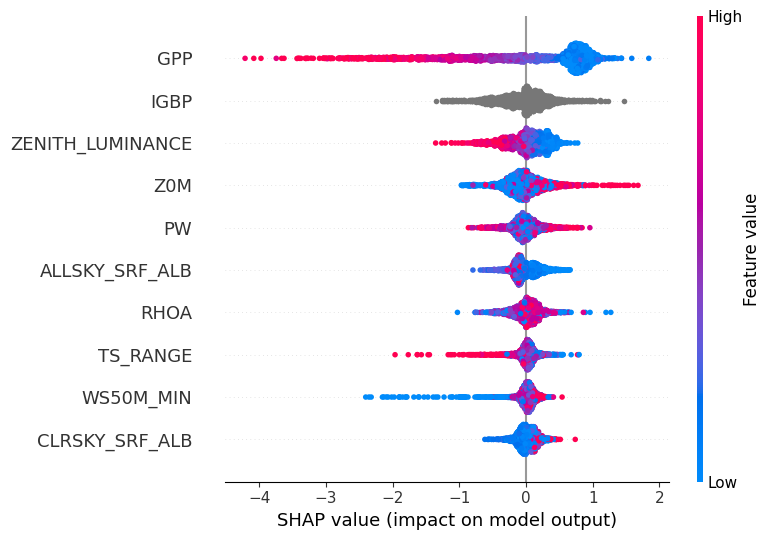

In [ ]:
shap.initjs()
# Calculate SHAP values
explainer = shap.TreeExplainer(model, data=X_train_scaled, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

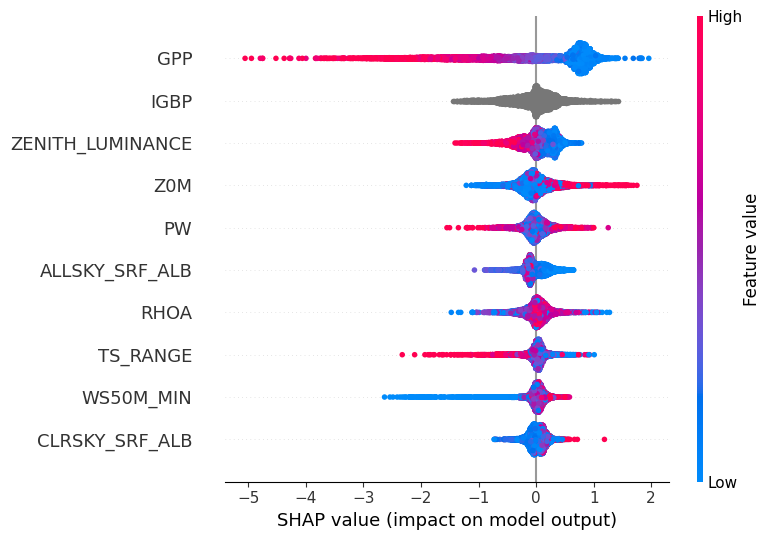

In [57]:
shap.initjs()
# Calculate SHAP values
# explainer = shap.TreeExplainer(model, data=X_train_scaled, feature_perturbation="tree_path_dependent")
# shap_values = explainer.shap_values(X_test_scaled)

shap_values = model.get_feature_importance(train_pool, type='ShapValues')
shap_values = shap_values[:, :-1]

shap.summary_plot(shap_values, X_train_scaled, plot_type="dot")

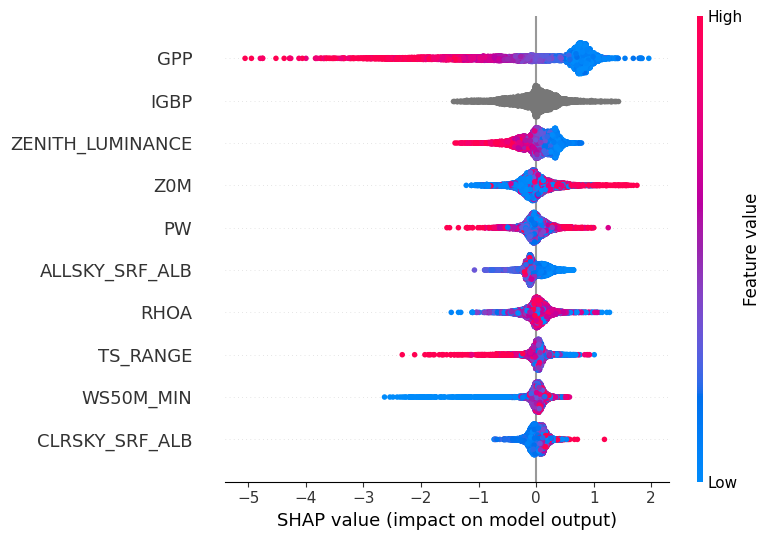

In [53]:
shap.summary_plot(shap_values, X_train_scaled, plot_type="dot")

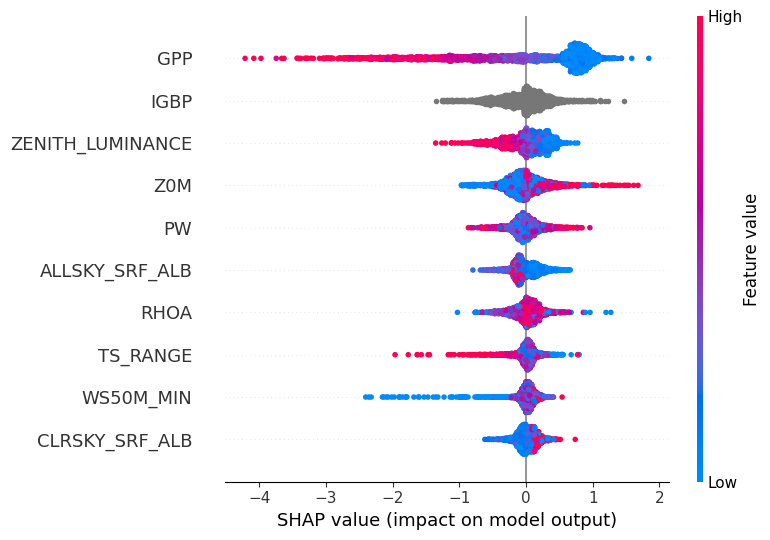

In [47]:
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

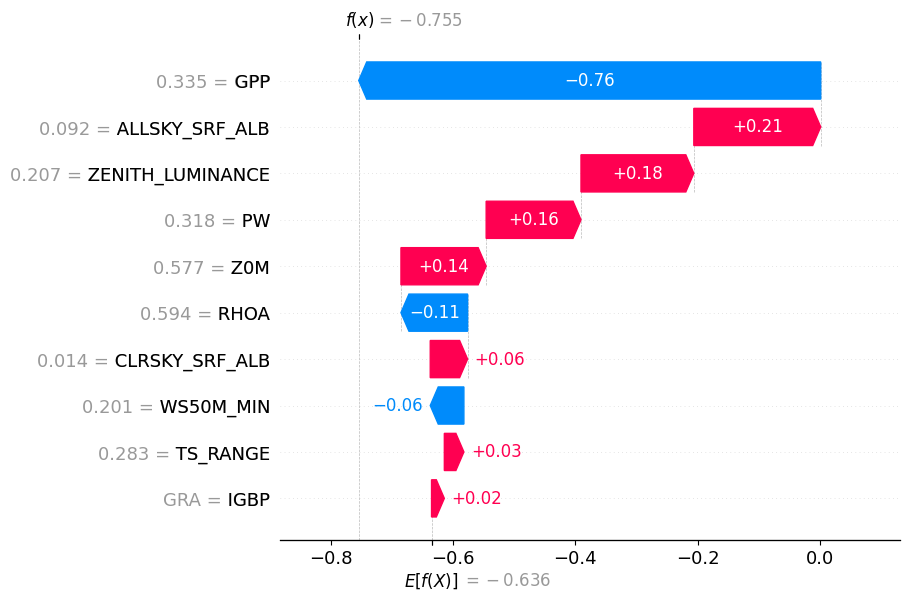

In [9]:
# Plot the SHAP values for a single prediction
shap.plots.waterfall(shap_values[10])

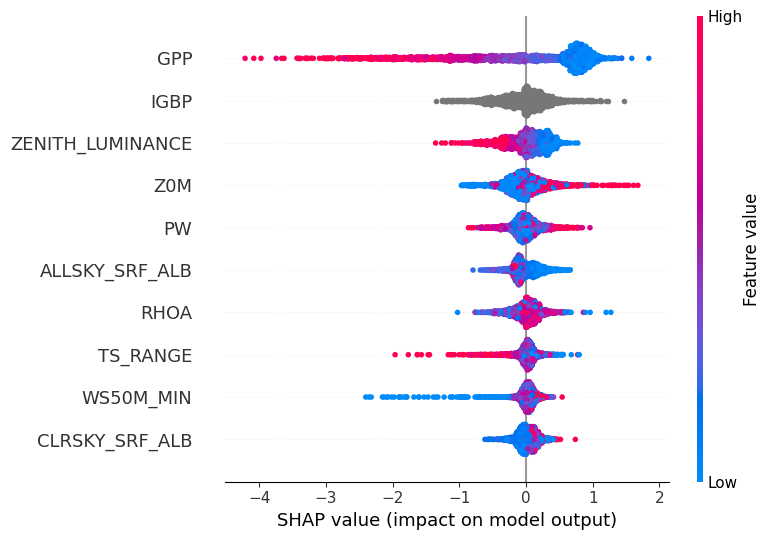

In [11]:
# Plot the summary of SHAP values for the entire test set
shap.summary_plot(shap_values, X_test_scaled)

In [22]:
shap.plots.force(shap_values[0, ...])

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [35]:
shap.plots.force(shap_values)

# PICP

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from catboost import CatBoostRegressor, Pool
import numpy as np

# Features to drop
features_to_drop = ['NEE']
X = cleaned_df.drop(features_to_drop, axis=1)
y = cleaned_df['NEE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Specify the categorical features
categorical_features = ['IGBP']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Separate categorical and numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Fit the scaler on the numerical training data and transform both training and testing numerical data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert scaled numerical data back to DataFrame
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=X_test_num.columns, index=X_test_num.index)

# Concatenate scaled numerical data with categorical data
X_train_scaled = pd.concat([X_train_num_scaled_df, X_train[categorical_features]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled_df, X_test[categorical_features]], axis=1)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_scaled, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test_scaled, label=y_test, cat_features=categorical_features)

# Train models for different quantiles
quantiles = [0.05, 0.95]
models = {}

for quantile in quantiles:
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100, loss_function='Quantile:alpha={}'.format(quantile))
    model.fit(train_pool)
    models[quantile] = model

# Make quantile predictions
predictions_lower = models[0.05].predict(test_pool)
predictions_upper = models[0.95].predict(test_pool)

# Calculate PICP
def calculate_picp(y_true, y_lower, y_upper):
    within_interval = np.logical_and(y_true >= y_lower, y_true <= y_upper)
    picp = np.mean(within_interval)
    return picp

picp = calculate_picp(y_test, predictions_lower, predictions_upper)
print(f'PICP: {picp}')

In other words, if you constructed prediction intervals such that you expect them to capture 90% of future observations (e.g., between the 5th and 95th percentiles), but your PICP is 0.8325, it indicates that only 83.25% of the actual observations are within these intervals. This might suggest that your prediction intervals are slightly narrower than desired, or that your model's uncertainty estimation is not perfectly aligned with the actual variability in the data.


To interpret this result:


If your target coverage was 90%, a PICP of 0.8325 suggests that your intervals are not capturing as many observations as expected, and you might need to adjust your model or interval estimation method.
If your target coverage was 80%, a PICP of 0.8325 indicates that your intervals are performing better than expected, capturing more observations than the target.

In general, the closer the PICP is to your desired coverage probability, the better your prediction intervals are performing.
